# Multiplex — Per-Label Sigmoid Threshold Grid Search

Post-hoc analysis of held-out test predictions from `03_main_training.py`.  
Finds the optimal sigmoid threshold per label (KPC / NDM / VIM) that maximises a chosen metric.  

**Strategy**: fully vectorised numpy — no sklearn in the inner loop.  
All 21³ = 9 261 threshold combinations are evaluated via tensor broadcasting in <100 ms per model.

In [ ]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import f1_score, accuracy_score, hamming_loss, precision_recall_fscore_support

_MULTIPLEX = Path('..').resolve()
sys.path.insert(0, str(_MULTIPLEX))
sys.path.insert(0, str(_MULTIPLEX / 'utils' / 'model_training'))

from model_utils_multilabel import ML_MODEL_KEY_MAP, ML_MODEL_PRINT_MAP
from config_multiplex import RESULT_FILE_BY_FLAG, RESULT_10FOLD_FILE_BY_FLAG

## Config

In [ ]:
EXP_FOLDER   = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex')
DATASET      = '01_ACA_qdPCR'
USE_10FOLD   = True   # True → _10fold.joblib; False → standard .joblib
FILTER_KEY   = None   # None = no outlier filter
THRESHOLDS   = np.arange(0, 1.01, 0.05)  # 21 values → 21^3 = 9 261 combos

RESULTS_DIR  = EXP_FOLDER / DATASET
_file_map    = RESULT_10FOLD_FILE_BY_FLAG if USE_10FOLD else RESULT_FILE_BY_FLAG

print(f'Results dir: {RESULTS_DIR}')
for flag, fname in _file_map.items():
    p = RESULTS_DIR / fname
    print(f'  [{flag}] {fname}  exists={p.exists()}')

## Load results

In [ ]:
# Merge all per-group result files into one dict
all_results = {}
loaded = []
for flag, fname in _file_map.items():
    path = RESULTS_DIR / fname
    if not path.exists():
        continue
    d = joblib.load(path)
    for fk, fv in d.items():
        all_results.setdefault(fk, {}).update(fv)
    loaded.append(flag)

if not all_results:
    raise FileNotFoundError(
        f'No result files found in {RESULTS_DIR}. Run 03_main_training.py first.'
    )

res_entry = all_results.get(FILTER_KEY)
if res_entry is None:
    available = list(all_results.keys())
    raise KeyError(f'FILTER_KEY={FILTER_KEY!r} not found. Available: {available}')

# Pool true labels across folds (same for all models)
y_true = np.concatenate(res_entry['y_trues_'], axis=0)  # (N, n_targets)
TARGETS = ['KPC', 'NDM', 'VIM']
N, n_targets = y_true.shape
assert n_targets == len(TARGETS)

n_probs = sum(1 for k in res_entry if k.startswith('y_probs_'))
print(f'Loaded groups : {loaded}')
print(f'N total samples: {N},  n_targets: {n_targets}')
print(f'Label prevalence: KPC={y_true[:,0].mean():.3f}  NDM={y_true[:,1].mean():.3f}  VIM={y_true[:,2].mean():.3f}')
print(f'Models in results: {n_probs} probs keys found')

## Vectorised threshold search function

In [4]:
def threshold_search(y_prob: np.ndarray, y_true: np.ndarray, thresholds: np.ndarray) -> dict:
    """
    Vectorised per-label threshold grid search.

    Parameters
    ----------
    y_prob      : (N, 3) float — raw sigmoid probabilities
    y_true      : (N, 3) int  — binary ground truth
    thresholds  : (T,) float  — candidate thresholds (e.g. np.arange(0, 1.01, 0.05))

    Returns
    -------
    dict with keys 'exact_match', 'hamming', 'f1_samples'.
    Each value: dict with 'thresholds' (list of per-label optimal threshold),
                'score' (float), 'score_3d' (21×21×21 numpy array).
    """
    N, L = y_true.shape
    T    = len(thresholds)

    # Pre-binarize: pj[n, t] = (y_prob[n, j] >= thresholds[t])  →  (N, T) per label
    p = [(y_prob[:, j:j+1] >= thresholds).astype(np.float32) for j in range(L)]  # L × (N, T)

    # correct[j][n, t] = (p[j][n, t] == y_true[n, j])
    c = [(p[j] == y_true[:, j:j+1]).astype(np.float32) for j in range(L)]

    # --- Exact match: exact[i,j,k] = mean_n(c0[n,i] & c1[n,j] & c2[n,k]) ---
    # = einsum('ni,nj,nk->ijk', c0, c1, c2) / N
    exact_3d = np.einsum('ni,nj,nk->ijk', c[0], c[1], c[2]) / N
    best_idx  = np.unravel_index(exact_3d.argmax(), exact_3d.shape)
    exact_res = {
        'thresholds': [float(thresholds[i]) for i in best_idx],
        'score':      float(exact_3d[best_idx]),
        'score_3d':   exact_3d,
    }

    # --- Hamming score (1 - hamming_loss): labels are independent → max per-label accuracy ---
    acc = [c[j].mean(axis=0) for j in range(L)]  # L × (T,)
    hamming_res = {
        'thresholds': [float(thresholds[acc[j].argmax()]) for j in range(L)],
        'score':      float(np.mean([acc[j].max() for j in range(L)])),
        'score_3d':   None,  # per-label independent — no joint tensor needed
    }

    # --- F1 samples: 2 * intersect / (pred_sum + true_sum) averaged over N ---
    # Requires (N, T, T, T) broadcast → ~18 MB at float32 for N=500, T=21 — fine
    i = [(p[j] * y_true[:, j:j+1]).astype(np.float32) for j in range(L)]
    true_s = y_true.sum(axis=1, keepdims=True).astype(np.float32)  # (N, 1)

    # Build 4D tensors (N, T, T, T) via broadcasting
    inter  = (i[0][:, :, None, None]
              + i[1][:, None, :, None]
              + i[2][:, None, None, :])   # (N, T, T, T)
    preds  = (p[0][:, :, None, None]
              + p[1][:, None, :, None]
              + p[2][:, None, None, :])   # (N, T, T, T)
    denom  = preds + true_s[:, None, None, :]  # broadcast true_s over (T,T,T)
    f1_4d  = (2 * inter / (denom + 1e-8)).mean(axis=0)  # (T, T, T)
    best_f1_idx = np.unravel_index(f1_4d.argmax(), f1_4d.shape)
    f1_res = {
        'thresholds': [float(thresholds[i]) for i in best_f1_idx],
        'score':      float(f1_4d[best_f1_idx]),
        'score_3d':   f1_4d,
    }

    return {'exact_match': exact_res, 'hamming': hamming_res, 'f1_samples': f1_res}

## Run search across all available models

In [35]:
rows = []

for model_name, (_, probs_key, _) in ML_MODEL_KEY_MAP.items():
    if probs_key not in res_entry:
        continue  # model not yet trained

    y_prob = np.concatenate(res_entry[probs_key], axis=0).astype(np.float32)  # (N, 3)
    sr     = threshold_search(y_prob, y_true.astype(np.float32), THRESHOLDS)

    # Baseline at 0.5
    y_base    = (y_prob >= 0.5).astype(np.int8)
    base_f1   = f1_score(y_true, y_base, average='samples',  zero_division=0)
    base_exact= accuracy_score(y_true, y_base)
    base_ham  = 1 - hamming_loss(y_true, y_base)

    label = ML_MODEL_PRINT_MAP.get(model_name, model_name)
    rows.append({
        'model_key':    model_name,
        'model_label':  label,
        # baseline
        'f1s_base':     base_f1,
        'exact_base':   base_exact,
        'ham_base':     base_ham,
        # optimal
        'f1s_opt':      sr['f1_samples']['score'],
        'exact_opt':    sr['exact_match']['score'],
        'ham_opt':      sr['hamming']['score'],
        # gain
        'f1s_gain':     sr['f1_samples']['score'] - base_f1,
        'exact_gain':   sr['exact_match']['score'] - base_exact,
        'ham_gain':     sr['hamming']['score'] - base_ham,
        # optimal thresholds
        'thr_kpc_f1s':  sr['f1_samples']['thresholds'][0],
        'thr_ndm_f1s':  sr['f1_samples']['thresholds'][1],
        'thr_vim_f1s':  sr['f1_samples']['thresholds'][2],
        'thr_kpc_exact':sr['exact_match']['thresholds'][0],
        'thr_ndm_exact':sr['exact_match']['thresholds'][1],
        'thr_vim_exact':sr['exact_match']['thresholds'][2],
        'thr_kpc_ham':  sr['hamming']['thresholds'][0],
        'thr_ndm_ham':  sr['hamming']['thresholds'][1],
        'thr_vim_ham':  sr['hamming']['thresholds'][2],
        # store score tensors for later analysis
        '_f1s_3d':      sr['f1_samples']['score_3d'],
        '_exact_3d':    sr['exact_match']['score_3d'],
    })

df = pd.DataFrame(rows)

## Summary table

In [41]:
from IPython.display import display

def print_search_summary(df, metric='exact'):
    df_temp = df.copy()
    df_temp = df_temp.sort_values(f'{metric}_opt', ascending=False).reset_index(drop=True)

    display_cols = [
        'model_label',
        f'{metric}_base', f'{metric}_opt', f'{metric}_gain',
        f'thr_kpc_{metric}', f'thr_ndm_{metric}', f'thr_vim_{metric}',
    ]

    # remove duplicate column names while preserving order
    uniq_cols = []
    for c in display_cols:
        if c not in uniq_cols:
            uniq_cols.append(c)

    fmt = {c: '{:.3f}' for c in uniq_cols if c != 'model_label'}

    styled_df = (
        df_temp[uniq_cols].style
        .format(fmt)
        .background_gradient(subset=[f'{metric}_gain'], cmap='RdYlGn')
        .set_caption(f'Optimal thresholds per model — sorted by best {metric}-samples')
    )

    display(styled_df)

print_search_summary(df, metric='exact')
print_search_summary(df, metric='ham')
print_search_summary(df, metric='f1s')

,model_label,exact_base,exact_opt,exact_gain,thr_kpc_exact,thr_ndm_exact,thr_vim_exact
0,CNN+GRU SC2,0.824,0.825,0.000,0.550,0.500,0.450
1,Trans RCFD CGD SC1,0.811,0.811,0.000,0.500,0.500,0.450
2,CNN+Tr CAttn SC1,0.811,0.811,0.000,0.500,0.550,0.500
3,CNN+Tr CAttn SC3,0.810,0.810,0.000,0.500,0.500,0.550
4,CNN+GRU SC1,0.808,0.808,0.000,0.500,0.500,0.450
5,CNN+Tr CAttn SC2,0.805,0.806,0.001,0.500,0.500,0.550
6,GRU RCFD CGD SC2,0.803,0.804,0.001,0.500,0.450,0.500
7,Trans RCFD CGD SC3,0.801,0.803,0.002,0.550,0.450,0.450
8,CNN+GRU SC3,0.800,0.801,0.001,0.500,0.450,0.500
9,Trans RCFD CGD SC2,0.799,0.800,0.001,0.550,0.450,0.450


,model_label,ham_base,ham_opt,ham_gain,thr_kpc_ham,thr_ndm_ham,thr_vim_ham
0,CNN+GRU SC2,0.921,0.921,0.000,0.550,0.500,0.500
1,CNN+Tr CAttn SC3,0.917,0.917,0.000,0.500,0.500,0.450
2,CNN+Tr CAttn SC1,0.917,0.917,0.000,0.500,0.500,0.500
3,Trans RCFD CGD SC1,0.915,0.916,0.000,0.450,0.550,0.500
4,CNN+Tr CAttn SC2,0.916,0.916,0.000,0.500,0.500,0.550
5,CNN+GRU SC1,0.915,0.915,0.000,0.500,0.500,0.450
6,GRU RCFD CGD SC2,0.913,0.913,0.000,0.500,0.450,0.500
7,Trans RCFD CGD SC3,0.913,0.913,0.000,0.500,0.450,0.450
8,Trans RCFD CGD SC2,0.912,0.913,0.000,0.450,0.450,0.450
9,CNN+GRU SC3,0.912,0.912,0.000,0.450,0.450,0.500


,model_label,f1s_base,f1s_opt,f1s_gain,thr_kpc_f1s,thr_ndm_f1s,thr_vim_f1s
0,CNN+GRU SC2,0.932,0.933,0.001,0.400,0.400,0.400
1,CNN+Tr CAttn SC3,0.927,0.929,0.002,0.400,0.400,0.400
2,Trans RCFD CGD SC1,0.927,0.928,0.002,0.450,0.400,0.450
3,CNN+Tr CAttn SC1,0.927,0.928,0.001,0.400,0.450,0.450
4,CNN+GRU SC1,0.926,0.927,0.001,0.400,0.400,0.450
5,CNN+Tr CAttn SC2,0.927,0.927,0.000,0.450,0.500,0.450
6,Trans RCFD CGD SC3,0.924,0.926,0.002,0.450,0.450,0.400
7,CNN+GRU SC3,0.923,0.926,0.003,0.450,0.400,0.400
8,GRU RCFD CGD SC2,0.924,0.925,0.001,0.450,0.450,0.450
9,Trans RCFD CGD SC2,0.923,0.924,0.002,0.450,0.400,0.450


## Gain from threshold tuning (bar chart)

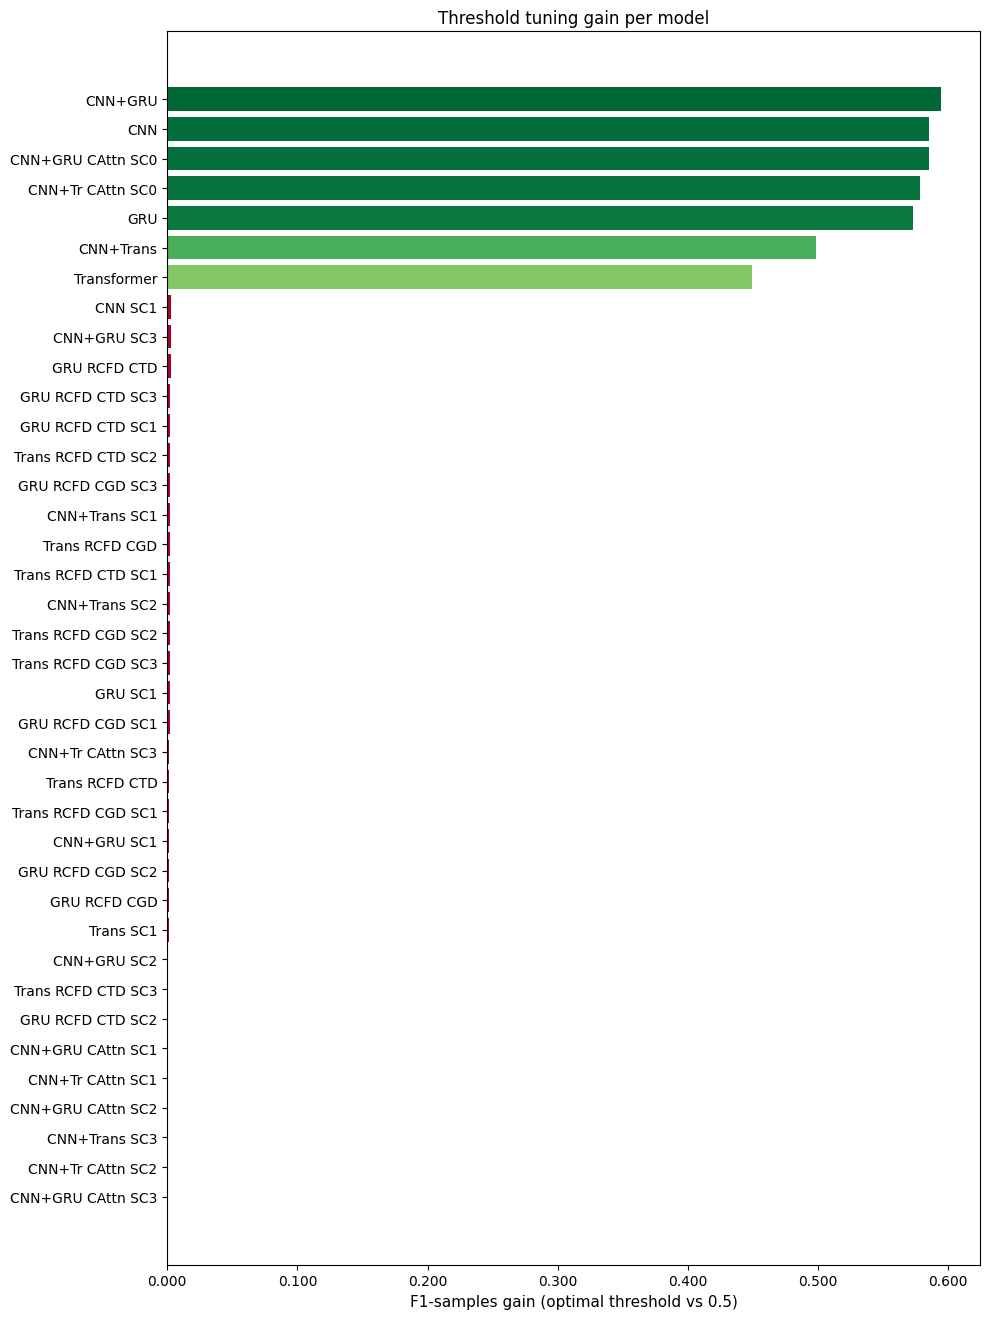


Top-5 models by F1-samples gain:
      model_label  f1s_base  f1s_opt  f1s_gain
          CNN+GRU  0.003839 0.598528  0.594689
              CNN  0.000019 0.585642  0.585623
CNN+GRU CAttn SC0  0.001960 0.586931  0.584971
 CNN+Tr CAttn SC0  0.008765 0.587303  0.578538
              GRU  0.010514 0.583214  0.572700


In [7]:
df_plot = df.sort_values('f1s_gain', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, n_models * 0.35)))
bars = ax.barh(df_plot['model_label'], df_plot['f1s_gain'],
               color=plt.cm.RdYlGn(df_plot['f1s_gain'] / (df_plot['f1s_gain'].max() + 1e-8)))
ax.set_xlabel('F1-samples gain (optimal threshold vs 0.5)', fontsize=11)
ax.set_title('Threshold tuning gain per model', fontsize=12)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax.axvline(0, color='grey', lw=0.8, ls='--')
plt.tight_layout()
plt.show()

print('\nTop-5 models by F1-samples gain:')
print(df.nlargest(5, 'f1s_gain')[['model_label', 'f1s_base', 'f1s_opt', 'f1s_gain']].to_string(index=False))

## Per-target optimal thresholds heatmap (all models)

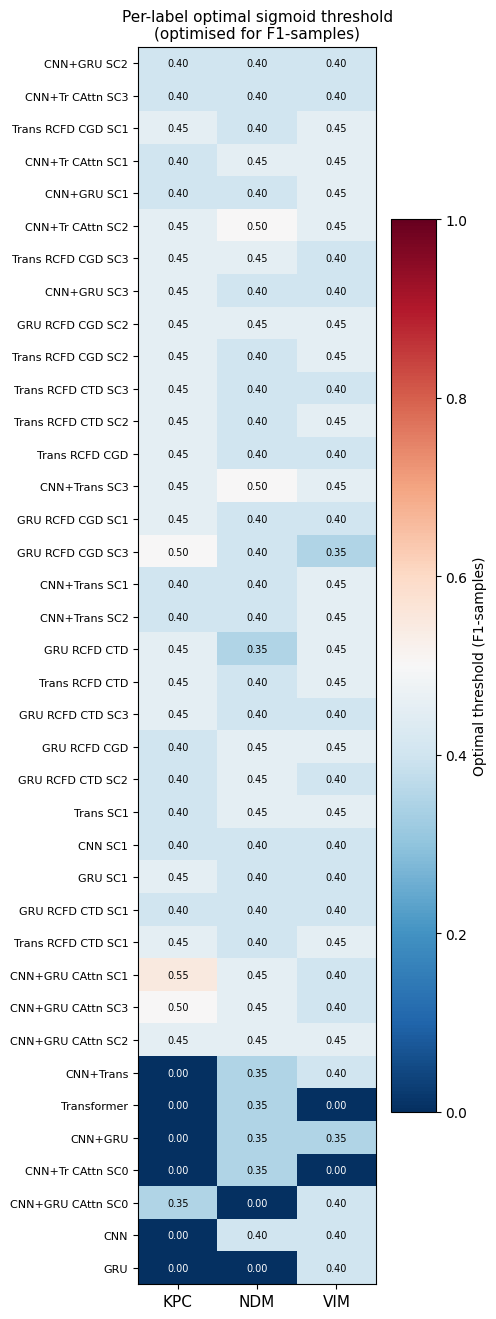

In [8]:
thr_data = df[['model_label', 'thr_kpc_f1s', 'thr_ndm_f1s', 'thr_vim_f1s']].copy()
thr_data = thr_data.set_index('model_label')
thr_data.columns = TARGETS

fig, ax = plt.subplots(figsize=(5, max(4, n_models * 0.35)))
im = ax.imshow(thr_data.values, aspect='auto', cmap='RdBu_r', vmin=0, vmax=1)
ax.set_xticks(range(n_targets))
ax.set_xticklabels(TARGETS, fontsize=11)
ax.set_yticks(range(n_models))
ax.set_yticklabels(thr_data.index, fontsize=8)
plt.colorbar(im, ax=ax, label='Optimal threshold (F1-samples)')
ax.set_title('Per-label optimal sigmoid threshold\n(optimised for F1-samples)', fontsize=11)

# Annotate cells
for i in range(n_models):
    for j in range(n_targets):
        val = thr_data.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='black' if 0.3 < val < 0.7 else 'white')

plt.tight_layout()
plt.show()

## 2D threshold landscape for the best model
Fix VIM at its optimal threshold; plot KPC vs NDM heatmap for F1-samples.

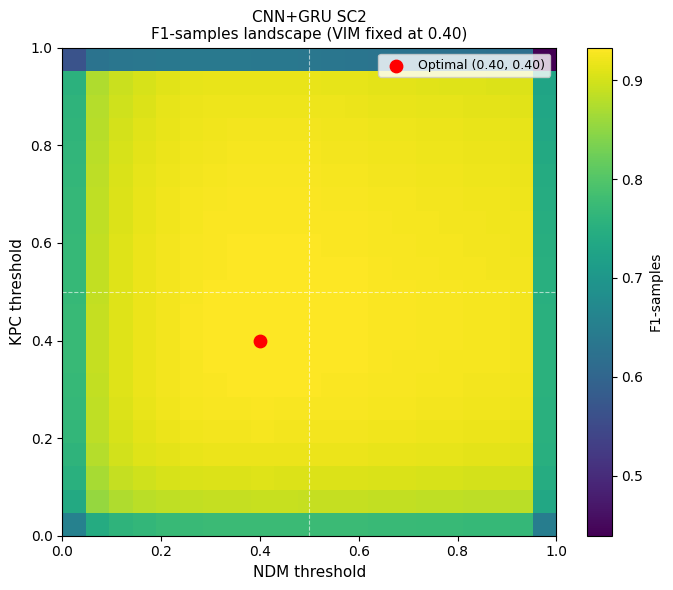

In [9]:
# Select model to inspect
INSPECT_IDX   = 0   # 0 = best model by f1s_opt; change to explore others
inspect_row   = df.iloc[INSPECT_IDX]
f1s_3d        = inspect_row['_f1s_3d']   # (21, 21, 21)
vim_opt_idx   = THRESHOLDS.tolist().index(inspect_row['thr_vim_f1s'])

slice_2d = f1s_3d[:, :, vim_opt_idx]  # KPC × NDM at fixed VIM threshold

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(slice_2d, origin='lower', aspect='auto', cmap='viridis',
               extent=[THRESHOLDS[0], THRESHOLDS[-1], THRESHOLDS[0], THRESHOLDS[-1]])
plt.colorbar(im, ax=ax, label='F1-samples')

# Mark optimal
ax.scatter([inspect_row['thr_ndm_f1s']], [inspect_row['thr_kpc_f1s']],
           color='red', s=80, zorder=5, label=f'Optimal ({inspect_row["thr_kpc_f1s"]:.2f}, {inspect_row["thr_ndm_f1s"]:.2f})')
ax.axvline(0.5, color='white', lw=0.8, ls='--', alpha=0.6)
ax.axhline(0.5, color='white', lw=0.8, ls='--', alpha=0.6)

ax.set_xlabel(f'NDM threshold', fontsize=11)
ax.set_ylabel(f'KPC threshold', fontsize=11)
ax.set_title(f'{inspect_row["model_label"]}\nF1-samples landscape (VIM fixed at {inspect_row["thr_vim_f1s"]:.2f})', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Per-label precision / recall at optimal vs 0.5 (best model)

Model: CNN+GRU SC2
Target  Optimal thr  P@opt  R@opt  F1@opt  P@0.5  R@0.5  F1@0.5
   KPC        0.400  0.911  0.912   0.912  0.937  0.889   0.912
   NDM        0.400  0.919  0.885   0.902  0.949  0.858   0.901
   VIM        0.400  0.939  0.864   0.900  0.967  0.840   0.899


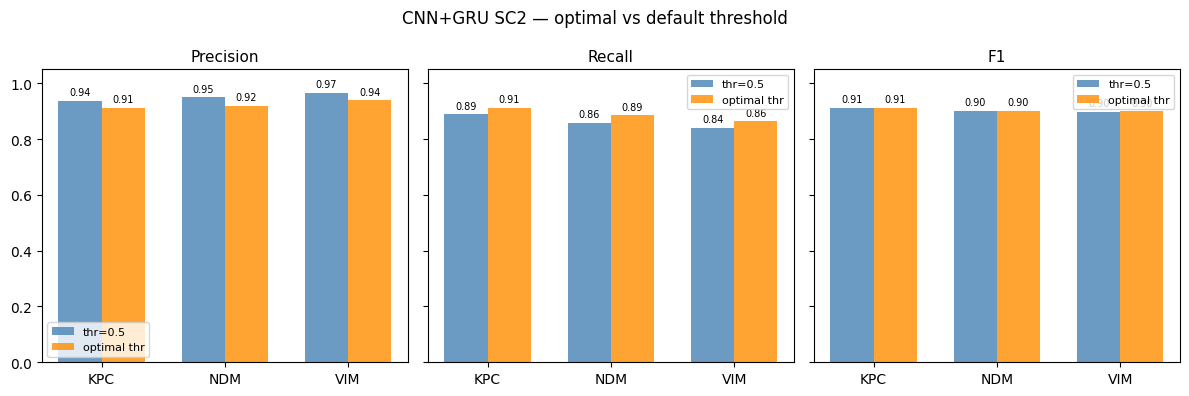

In [10]:
best_row   = df.iloc[0]
model_key  = best_row['model_key']
y_prob_best = np.concatenate(
    res_entry[ML_MODEL_KEY_MAP[model_key][1]], axis=0).astype(np.float32)

thr_opt    = np.array([best_row['thr_kpc_f1s'], best_row['thr_ndm_f1s'], best_row['thr_vim_f1s']])
y_pred_opt = (y_prob_best >= thr_opt).astype(np.int8)
y_pred_def = (y_prob_best >= 0.5).astype(np.int8)

p_opt, r_opt, f_opt, _ = precision_recall_fscore_support(y_true, y_pred_opt, zero_division=0)
p_def, r_def, f_def, _ = precision_recall_fscore_support(y_true, y_pred_def, zero_division=0)

metrics_df = pd.DataFrame({
    'Target':          TARGETS,
    'Optimal thr':     thr_opt,
    'P@opt':  p_opt, 'R@opt':  r_opt, 'F1@opt':  f_opt,
    'P@0.5':  p_def, 'R@0.5':  r_def, 'F1@0.5':  f_def,
})

print(f'Model: {best_row["model_label"]}')
print(metrics_df.to_string(index=False, float_format='{:.3f}'.format))

# Bar chart comparison
x = np.arange(n_targets)
w = 0.35
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, metric, opt_vals, def_vals, ylabel in zip(
    axes,
    ['Precision', 'Recall', 'F1'],
    [p_opt, r_opt, f_opt],
    [p_def, r_def, f_def],
    ['Score'] * 3,
):
    ax.bar(x - w/2, def_vals, w, label='thr=0.5', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, opt_vals, w, label='optimal thr', color='darkorange', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(TARGETS)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    for xi, (dv, ov) in enumerate(zip(def_vals, opt_vals)):
        ax.text(xi - w/2, dv + 0.02, f'{dv:.2f}', ha='center', fontsize=7)
        ax.text(xi + w/2, ov + 0.02, f'{ov:.2f}', ha='center', fontsize=7)

fig.suptitle(f'{best_row["model_label"]} — optimal vs default threshold', fontsize=12)
plt.tight_layout()
plt.show()